In [1]:
import sys
sys.path.append('..')
from src.order_book import OrderBook, Side
from src.market_maker import MarketMaker
from src.simulator import Simulator

import requests
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
def get_btc_trades(limit=1000):
    url = "https://api.exchange.coinbase.com/products/BTC-USD/trades"
    params = {"limit": limit}
    response = requests.get(url, params=params)
    data = response.json()
    df = pd.DataFrame(data)
    return df

trades = get_btc_trades()
print(f"Got {len(trades)} trades")

trades['price'] = pd.to_numeric(trades['price'])
trades['size'] = pd.to_numeric(trades['size'])
trades['time'] = pd.to_datetime(trades['time'])

trades = trades.sort_values('time').reset_index(drop=True)
trades = trades.set_index("time")


print(trades.dtypes)
trades.head()

Got 1000 trades
trade_id      int64
side         object
size        float64
price       float64
dtype: object


,trade_id,side,size,price
time,,,,
2026-05-18 16:32:52.406547+00:00,1020566338,sell,0.006519,76309.99
2026-05-18 16:32:52.407677+00:00,1020566339,sell,0.003807,76310.00
2026-05-18 16:32:52.412916+00:00,1020566340,sell,0.006300,76312.00
2026-05-18 16:32:52.414808+00:00,1020566341,sell,0.003259,76311.99
2026-05-18 16:32:52.666112+00:00,1020566343,buy,0.006552,76314.46


In [3]:
book = OrderBook()
mm = MarketMaker(starting_wealth=100000, order_book=book)
sim = Simulator(mm=mm, book=book, df=trades, window=20)

mm.start_session()
sim.run()

In [4]:
results = sim.get_results()
results.tail(10)

,Mid_Price,Reservation_Price,Bid,Ask,Position,PnL,Spread
Time,,,,,,,
990,76340.0025,76340.230898,76339.385514,76341.076282,-0.571000,-5.949305,1.690768
991,76340.7040,76340.933354,76340.087970,76341.778738,-0.573390,-6.332424,1.690768
992,76341.3005,76341.529854,76340.684471,76342.375238,-0.573390,-6.674450,1.690768
993,76341.8970,76342.130354,76341.284970,76342.975738,-0.583390,-6.976447,1.690768
994,76342.4930,76342.726992,76341.881608,76343.572376,-0.584984,-7.318715,1.690768
995,76343.0890,76343.323002,76342.477618,76344.168386,-0.585008,-7.667299,1.690768
996,76343.6850,76343.919426,76343.074043,76344.764810,-0.586070,-8.013611,1.690768
997,76344.2070,76344.441426,76343.596043,76345.286810,-0.586070,-8.319540,1.690768
998,76344.6785,76344.912926,76344.067543,76345.758310,-0.586070,-8.595872,1.690768


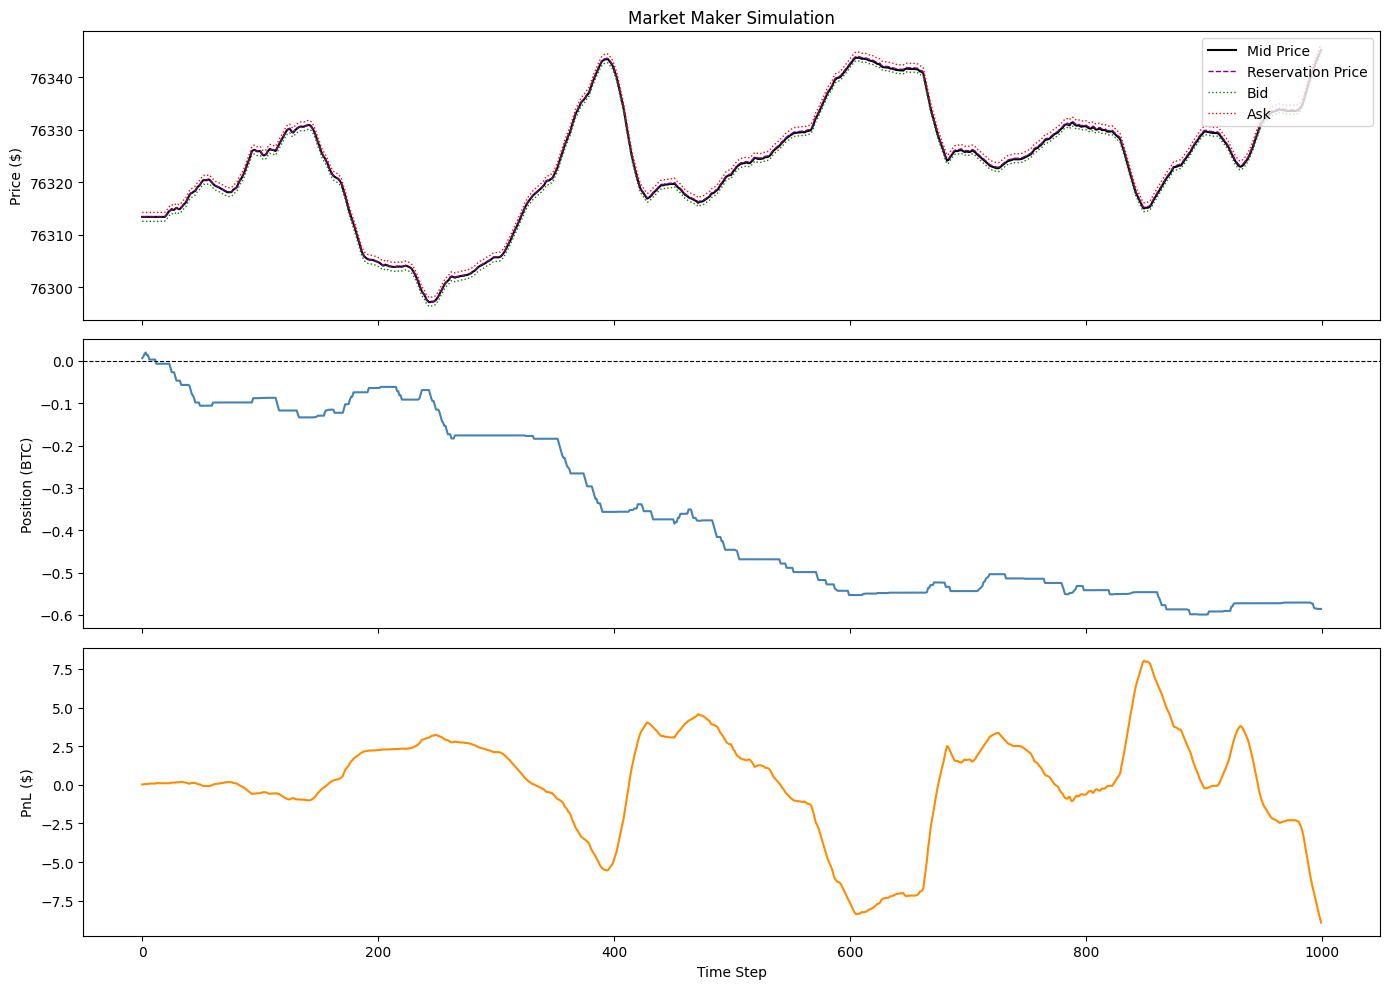

In [6]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

ax1.plot(results.index, results['Mid_Price'], label='Mid Price', color='black', linewidth=1.5)
ax1.plot(results.index, results['Reservation_Price'], label='Reservation Price', color='purple', linewidth=1, linestyle='--')
ax1.plot(results.index, results['Bid'], label='Bid', color='green', linewidth=1, linestyle=':')
ax1.plot(results.index, results['Ask'], label='Ask', color='red', linewidth=1, linestyle=':')
ax1.set_ylabel('Price ($)')
ax1.legend(loc='upper right')
ax1.set_title('Market Maker Simulation')

ax2.plot(results.index, results['Position'], color='steelblue', linewidth=1.5)
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_ylabel('Position (BTC)')

ax3.plot(results.index, results['PnL'], color='darkorange', linewidth=1.5)
ax3.set_ylabel('PnL ($)')
ax3.set_xlabel('Time Step')

plt.tight_layout()
plt.show()